# priya_loader — quick-start tutorial

`priya_loader` turns the PRIYA MP-Gadget Lyman-α simulation suite into ML-ready
3-D numpy arrays. The headline object `PriyaDataset` loops over every
simulation/redshift and yields `[SimParams, redshift, ic, tau]`.

This tutorial runs **anywhere** — it builds a tiny *synthetic* PRIYA-shaped
simulation so every cell executes in seconds without the real (multi-GB) data.
The last section shows how to point at the real suite.

Requires: `pip install -e ".[ic,plots]"` (numpy, h5py, bigfile, matplotlib).

In [1]:
import json, tempfile
from pathlib import Path
import numpy as np
import h5py, bigfile
%matplotlib inline
import matplotlib.pyplot as plt

import priya_loader as pl
from priya_loader import (discover_simulations, SimParams, load_tau_grid,
                          load_ic_density, load_ic_particles, PriyaDataset, to_flux)
print("priya_loader", pl.__version__)

priya_loader 0.1.0.dev0


## 1. A tiny synthetic PRIYA simulation

A real sim folder has: a param-encoded name, `SimulationICs.json`, the
authoritative run configs (`mpgadget.param`, `_genic_params.ini`), an
`ICS/<box>_<Ngrid>_99/` bigfile (gas=0, DM=1 particles with `Position`,
`ID`, `ICDensity`), and `output/SPECTRA_NNN/lya_forest_spectra_grid_480.hdf5`
gridded optical depth. We synthesise a miniature one (Ngrid=8, a 4×4×3 tau grid).

In [2]:
ROOT = Path(tempfile.mkdtemp()) / "emu_full"
NAME = ("ns0.905Ap1.79e-09herei3.97heref2.99alphaq2.1hub0.745"
        "omegamh20.145hireionz7.47bhfeedback0.043")
JSON = {"box": 15, "npart": 192,           # deliberately STALE (run files win)
        "omega0": 0.262060, "omegab": 0.040359, "hubble": 0.745,
        "scalar_amp": 2.32278e-09, "ns": 0.904734, "redshift": 99, "redend": 2.0,
        "here_i": 3.97460, "here_f": 2.98721, "alpha_q": 2.09593,
        "hireionz": 7.46623, "bhfeedback": 0.043015}

def write_ic(path, ng=8, box=120000.0):
    g = (np.arange(ng) + 0.5) * box / ng
    X, Y, Z = np.meshgrid(g, g, g, indexing="ij")
    pos = np.stack([X.ravel(), Y.ravel(), Z.ravel()], 1).astype("f8")
    i = np.arange(ng**3) // (ng*ng)
    with bigfile.File(str(path), create=True) as bf:
        bf.create_from_array("1/Position", pos)
        bf.create_from_array("1/ID", (np.arange(ng**3) + 1).astype("u8"))
        bf.create_from_array("1/ICDensity", np.sin(2*np.pi*i/ng).astype("f4"))  # mock linear delta_1
        bf.create("Header")
        for k, v in dict(BoxSize=box, Redshift=99.0, HubbleParam=0.745,
                         Omega0=0.262, OmegaLambda=0.738).items():
            bf["Header"].attrs[k] = v

def write_tau(path, ng=4, nbins=8, z=4.2, box=120000.0):
    per = ng*ng; nlos = 3*per
    gg = np.arange(nlos)[:, None]; kk = np.arange(nbins)[None, :]
    with h5py.File(path, "w") as f:
        f.create_dataset("tau/H/1/1215", data=(0.01*(gg % per) + 0.5*kk).astype("f4"))
        f.create_group("spectra").create_dataset("axis", data=np.repeat([1,2,3], per).astype("i4"))
        h = f.create_group("Header")
        h.attrs.update(redshift=z, nbins=nbins, box=box, hubble=0.745,
                       omegam=0.262, omegab=0.040, omegal=0.738, Hz=500.0)

d = ROOT / NAME
(d / "output" / "SPECTRA_004").mkdir(parents=True)
(d / "SimulationICs.json").write_text(json.dumps(JSON))
# Run config declares the real production grid (so SimParams validates to 120/1536);
# the toy IC bigfile holds 8^3 particles -- a real one has 1536^3.
(d / "mpgadget.param").write_text("InitCondFile = ICS/120_1536_99\n")
(d / "_genic_params.ini").write_text("Ngrid = 1536\nBoxSize = 120000\nNgridNu = 0\n")
write_ic(d / "ICS" / "120_1536_99")
write_tau(d / "output" / "SPECTRA_004" / "lya_forest_spectra_grid_480.hdf5")
print("synthetic suite at", ROOT)

synthetic suite at /tmp/tmpjhkkpgfv/emu_full


## 2. Parameters

Box and Ngrid come from the **authoritative run files** — note `box`/`npart`
are 120/1536 here even though the JSON says the stale `15`/`192`.

In [3]:
sims = discover_simulations(ROOT)
p = SimParams.from_dir(sims[0].directory)
print("name      :", p.name[:48], "...")
print("box, npart:", p.box, "Mpc/h ,", p.npart, "  (JSON said 15 / 192)")
print("fidelity  :", p.fidelity, "  z:", [p.z_end, p.z_init])
print("cosmo vec :", p.as_vector(["ns","scalar_amp","hubble","omega0"]))

name      : ns0.905Ap1.79e-09herei3.97heref2.99alphaq2.1hub0 ...
box, npart: 120.0 Mpc/h , 1536   (JSON said 15 / 192)
fidelity  : lowres   z: [2.0, 99.0]
cosmo vec : [9.04734e-01 2.32278e-09 7.45000e-01 2.62060e-01]


## 3. Lyman-α optical depth (`tau`)

`load_tau_grid` returns the **raw** tau cube for one line-of-sight axis,
`(ngrid, ngrid, nbins)` — redshift-space, LOS = last (velocity) axis. We plot the
transmitted flux `F = exp(-tau)`.

tau shape: (4, 4, 8)  z = 4.2  cube_axes = ('y', 'z', 'x')  dv_kms = 1935.98  space = redshift


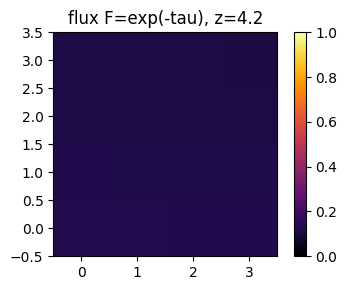

In [4]:
g = load_tau_grid(ROOT/NAME/"output"/"SPECTRA_004"/"lya_forest_spectra_grid_480.hdf5", axis=1)
print("tau shape:", g.tau.shape, " z =", g.redshift, " cube_axes =", g.cube_axes,
      " dv_kms =", round(g.meta["dv_kms"], 2), " space =", g.meta["space"])
flux = to_flux(g.tau)
plt.figure(figsize=(4,3))
plt.imshow(flux[:, :, flux.shape[2]//2], origin="lower", cmap="inferno", vmin=0, vmax=1)
plt.title(f"flux F=exp(-tau), z={g.redshift}"); plt.colorbar(); plt.tight_layout(); plt.show()

## 4. Initial conditions — three ways

**Which to use?** For the *bias cross-spectrum* you want the **linear δ₁** — use
`field="icdensity"` (no CIC). If you'd rather mesh yourself, get the raw particles.
The default `field="cic"` gives the Eulerian density of the displaced particles.

### 4a. Linear δ₁ via `field="icdensity"` — **no CIC** (recommended for bias)

Reshapes the native `ICDensity` block (the linear density contrast) onto the
Lagrangian grid by `ID`. This is the exact field a field-level bias estimator
wants — no CIC window, no painting.

delta_1: (8, 8, 8)  mean ~ 0.0  field = icdensity  space = real


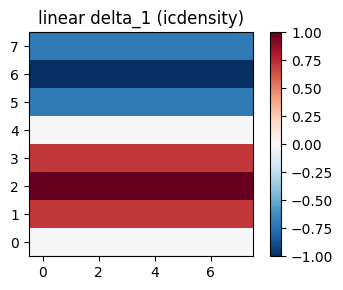

In [5]:
lin = load_ic_density(ROOT/NAME/"ICS"/"120_1536_99", ptype="dm", nmesh=8, field="icdensity")
print("delta_1:", lin.delta.shape, " mean ~", round(float(lin.delta.mean()), 4),
      " field =", lin.meta["field"], " space =", lin.space)
plt.figure(figsize=(4,3))
plt.imshow(lin.delta[:, :, 0], origin="lower", cmap="RdBu_r"); plt.title("linear delta_1 (icdensity)")
plt.colorbar(); plt.tight_layout(); plt.show()

### 4b. Raw particle table — mesh with your own nbodykit/Pylians

`load_ic_particles` returns the raw columns (no meshing). Use this if you want
full control of the mass assignment.

In [6]:
data, header = load_ic_particles(ROOT/NAME/"ICS"/"120_1536_99", ptype="dm",
                                 columns=("Position", "ICDensity", "ID"))
print("Position:", data["Position"].shape, "(comoving kpc/h)")
print("ICDensity:", data["ICDensity"].shape, " ID:", data["ID"].shape)
print("header:", {k: round(v, 3) if isinstance(v, float) else v for k, v in header.items()})
# e.g. paint with Pylians:  MAS_library.MA(data["Position"].astype("f4"), grid, box, "CIC")

Position: (512, 3) (comoving kpc/h)
ICDensity: (512,)  ID: (512,)
header: {'box_kpc_h': 120000.0, 'box_mpc_h': 120.0, 'hubble': 0.745, 'redshift': 99.0}


### 4c. CIC Eulerian density via `field="cic"` (default)

Streams `Position` and paints with the built-in numpy CIC (verified bit-for-bit
vs an explicit reference and vs Pylians). Returns `delta = rho/<rho> - 1`.

cic delta: (8, 8, 8)  mean ~ 0.0  axes = ('x', 'y', 'z')


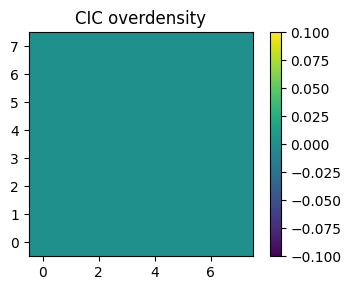

In [7]:
cic = load_ic_density(ROOT/NAME/"ICS"/"120_1536_99", ptype="dm", nmesh=8, field="cic")
print("cic delta:", cic.delta.shape, " mean ~", round(float(cic.delta.mean()), 6),
      " axes =", cic.axes)
plt.figure(figsize=(4,3))
plt.imshow(cic.delta[:, :, 0], origin="lower", cmap="viridis"); plt.title("CIC overdensity")
plt.colorbar(); plt.tight_layout(); plt.show()

## 5. `PriyaDataset` — the headline loop + export

Iterate over every (sim, redshift) → `Sample(params, redshift, ic, tau)`. Choose
the IC field with `ic_field`. `.export()` writes one self-describing `.npz` per
(sim, z).

In [8]:
ds = PriyaDataset(ROOT, ic_nmesh=8, ic_field="icdensity", flux_axis=1)
for s in ds:
    print("sample:", s.params.name[:28], "...  z =", s.redshift,
          " ic", s.ic.shape, " tau", s.tau.shape)
    print("  as_tuple ->", type(s.as_tuple()), "of length", len(s.as_tuple()))

out = Path(tempfile.mkdtemp())
paths = ds.export(out)
z = np.load(paths[0], allow_pickle=True)
print("\nexported npz keys:", list(z.keys()))
print("  resolved params box/npart:", json.loads(str(z["params"]))["box"],
      "/", json.loads(str(z["params"]))["npart"])
print("  meta:", json.loads(str(z["meta"]))["ic_field"], json.loads(str(z["meta"]))["tau_cube_axes"])

sample: ns0.905Ap1.79e-09herei3.97he ...  z = 4.2  ic (8, 8, 8)  tau (4, 4, 8)
  as_tuple -> <class 'tuple'> of length 4

exported npz keys: ['ic', 'tau', 'redshift', 'params', 'meta']
  resolved params box/npart: 120.0 / 1536
  meta: icdensity ['y', 'z', 'x']


## 6. Co-registration & growth — the consumer's job

The loader only *loads*; for the bias cross-spectrum `b_F = P_{F,δ}/P_{δδ}` you:
- **rescale** the IC `δ₁` from z_init≈99 to the flux redshift by the growth factor
  `D(z_flux)/D(99)` — `priya_loader.units.growth_factor(z, Om, OL)`; `meta`/`params`
  carry `Omega0/OmegaLambda/Time`;
- **co-register** with the anisotropic τ cube `(480,480,nbins)` (redshift-space
  velocity LOS): with `field="cic"` paint at `nmesh=480` and transpose to
  `tau.cube_axes`; with `field="icdensity"` load at a **divisor** of `ngrid`
  (256/384/512 — **never 480**, which divides neither 1536 nor 3072) and cross with
  τ in **Fourier space** over the common low-`k` modes; resample the LOS separately;
- **deconvolve** the IC window (CIC `sinc²`, or the `icdensity` block-average `sinc`);
- pick the **mean-flux** normalization (and whether to mask DLAs) for `δ_F`.

## 7. On the real suite

Just swap the root (paths are never hard-coded):

```python
from priya_loader import PriyaDataset
ROOT = "/path/to/priya/emu_full"        # Great Lakes / NERSC
# linear delta_1 for the bias cross-spectrum: nmesh must DIVIDE ngrid (512 | 1536, 3072):
ds = PriyaDataset(ROOT, fidelity="lowres", ic_nmesh=512, ic_field="icdensity", flux_axis=1)
# (to cross with the 480 tau transverse grid, Fourier-match low-k modes — do NOT use nmesh=480
#  with icdensity. For the cic field, ic_nmesh=480 co-registers directly.)
for sample in ds:                        # lazy; one (sim, z) at a time
    ...                                  # sample.params, .redshift, .ic, .tau
ds.export("/scratch/.../priya_npz")      # one .npz per (sim, z) for your JAX pipeline
```

Note: one real τ axis is ~1.5 GB; the IC reads are I/O-bound (81 GB/type at 1536³).
Use `ic_nmesh ≤ 512` on a login node (see the README memory table).